<a href="https://colab.research.google.com/github/gabriel-picussa/MVP-de-CEP---Gabriel-Picussa/blob/main/MVP_CEP_Laticinios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — CEP para Laticinios (I-MR e Xbar-R rolling)
Este notebook implementa um MVP de Controle Estatistico de Processos (CEP) para a industria laticinia usando a base `milknew_organizado.xlsx` hospedada no GitHub. Ele monitora as variaveis continuas **pH** e **Temperature** por meio das cartas **I-MR** e, opcionalmente, **Xbar-R** com janelas deslizantes (rolling). Os graficos usam CL verde tracejada, UCL/LCL vermelhos tracejados e pontos fora de controle em vermelho.

## Passo 1 — Configuracoes e imports
Definimos parametros do experimento e importamos as bibliotecas. `RAW_URL` e `FILE_NAME` servem para baixar a planilha automaticamente. A carta I-MR sempre e executada; a Xbar-R (rolling) e opcional via `USE_ROLLING_XBARR`. `ROLL_N`, `ROLL_STEP` e `ROLL_MIN_R` regulam o tamanho/qualidade dos subgrupos deslizantes (descartando janelas com R~0).

In [1]:
RAW_URL   = "https://raw.githubusercontent.com/gabriel-picussa/MVP-de-CEP---Gabriel-Picussa/main/milknew_organizado.xlsx"
FILE_NAME = "milknew_organizado.xlsx"

USE_ROLLING_XBARR = True
ROLL_N            = 5
ROLL_STEP         = 1
ROLL_MIN_R        = 1e-12

import os, math, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12, 4)


## Passo 2 — Download e leitura do Excel (GitHub RAW)
Implementamos uma funcao para baixar o arquivo diretamente do GitHub. Em caso de link com `/blob/`, usamos um fallback para `?raw=1`. Lemos o Excel com `pandas.read_excel`.

In [2]:
def load_excel_from_raw(url, dst_path):
    try:
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        with open(dst_path, "wb") as f:
            f.write(r.content)
        return dst_path
    except Exception as e:
        try:
            if "github.com" in url and "/blob/" in url:
                alt = url.replace("/blob/", "/") + "?raw=1"
            else:
                alt = url
            r = requests.get(alt, timeout=60)
            r.raise_for_status()
            with open(dst_path, "wb") as f:
                f.write(r.content)
            return dst_path
        except Exception as e2:
            raise RuntimeError(f"Falha no download: {e} | Fallback: {e2}")

path = load_excel_from_raw(RAW_URL, FILE_NAME)
df = pd.read_excel(path)
print("Arquivo lido:", path)


Arquivo lido: milknew_organizado.xlsx


## Passo 3 — Limpeza e padronizacao
Padronizamos nomes de colunas, corrigimos inconsistencias e removemos linhas 100% vazias. Tambem resetamos o indice. O resultado sao dimensoes, colunas e algumas linhas iniciais ja padronizadas.

In [3]:
if "Temprature" in df.columns and "Temperature" not in df.columns:
    df = df.rename(columns={"Temprature": "Temperature"})
df.columns = df.columns.str.strip()
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="ignore")
df = df.dropna(how="all").reset_index(drop=True)

print("Dimensoes:", df.shape)
print("Colunas:", list(df.columns))
display(df.head())


Dimensoes: (1059, 8)
Colunas: ['pH', 'Temperature', 'Taste', 'Odor', 'Fat', 'Turbidity', 'Colour', 'Grade']


/tmp/ipython-input-3223583005.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


,pH,Temperature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,3.0,40,1,1,1,1,255,low
1,3.0,40,1,0,0,0,255,low
2,3.0,40,1,1,1,1,255,low
3,3.0,40,1,1,1,1,255,low
4,3.0,40,1,0,0,0,255,low


## Passo 4 — Utilidades (funcoes auxiliares)
Criamos funcoes de apoio para identificar pontos fora de controle, evitar duplicacao de legendas e padronizar os graficos. Nao ha saida ainda; apenas deixamos pronto para os proximos passos.

In [4]:
import numpy as _np
def _ooc_idx(vals, lic, lsc):
    return _np.where((vals < lic) | (vals > lsc))[0]

def _legend_nodup():
    h, l = plt.gca().get_legend_handles_labels()
    uniq = dict(zip(l, h))
    plt.legend(uniq.values(), uniq.keys(), loc='upper right', frameon=True)

def plot_series(var_name, y, LIC, LC, LSC, title, ylabel=None, x_is_subgroup=False):
    idx = _np.arange(1, len(y)+1)
    fora = _ooc_idx(y, LIC, LSC)
    plt.figure()
    plt.plot(idx, y, marker='o', linewidth=1.8)
    plt.axhline(LC,  linestyle='--', color='green', label='CL')
    plt.axhline(LSC, linestyle='--', color='red',   label='UCL')
    plt.axhline(LIC, linestyle='--', color='red',   label='LCL')
    if len(fora):
        plt.scatter(idx[fora], y[fora], color='red', s=70, label='Fora de controle')
    plt.title(title)
    plt.xlabel('Subgrupo' if x_is_subgroup else 'Indice')
    plt.ylabel(ylabel or var_name)
    _legend_nodup()
    plt.tight_layout()
    plt.show()


## Passo 5 — Carta I-MR
Calculamos I, MR e seus limites de controle classicos de 3 sigma. CL = media Xbar; UCL/LCL = Xbar +- 3*sigma, com sigma estimado por MRbar/d2 (d2=1.128). Para MR, UCL=3.267*MRbar e LCL=0. Geramos dois graficos (I e MR) e imprimimos um resumo com Xbar, MRbar, sigma e limites.

In [5]:
def imr(y, var_name):
    x = y.values.astype(float)
    I  = x
    MR = np.abs(np.diff(x))

    Xbar  = I.mean()
    MRbar = MR.mean()
    d2 = 1.128
    sigma = MRbar / d2 if d2 > 0 else np.nan

    LIC_I, LC_I, LSC_I = Xbar - 3*sigma, Xbar, Xbar + 3*sigma
    D4, D3 = 3.267, 0.0
    LIC_MR, LC_MR, LSC_MR = D3*MRbar, MRbar, D4*MRbar

    print(f"\n=== {var_name} :: I-MR ===")
    print(f"Xbar={Xbar:.4f} | MRbar={MRbar:.4f} | sigma~{sigma:.4f}")
    print(f"I:  LCL={LIC_I:.4f}, CL={LC_I:.4f}, UCL={LSC_I:.4f}")
    print(f"MR: LCL={LIC_MR:.4f}, CL={LC_MR:.4f}, UCL={LSC_MR:.4f}")

    plot_series(var_name, I, LIC_I, LC_I, LSC_I, f"I chart - {var_name}", var_name, x_is_subgroup=False)

    idx = np.arange(2, len(MR)+2)
    plt.figure()
    plt.plot(idx, MR, marker='o', linewidth=1.8)
    plt.axhline(LC_MR,  linestyle='--', color='green', label='CL')
    plt.axhline(LSC_MR, linestyle='--', color='red',   label='UCL')
    plt.axhline(LIC_MR, linestyle='--', color='red',   label='LCL')
    fora = _ooc_idx(MR, LIC_MR, LSC_MR)
    if len(fora):
        plt.scatter(idx[fora], MR[fora], color='red', s=70, label='Fora de controle')
    plt.title('MR chart - |Delta|')
    plt.xlabel('Indice')
    plt.ylabel('|Delta|')
    _legend_nodup()
    plt.tight_layout()
    plt.show()


## Passo 6 — Carta Xbar-R (rolling, opcional)
Formamos subgrupos por janelas deslizantes de tamanho ROLL_N. Para cada janela calculamos a media (Xbar) e a amplitude (R). Aplicamos as constantes A2, D3, D4 para obter limites classicos 3 sigma. Geramos graficos X e R por variavel, com pontos fora de controle.

In [6]:
CONST = {
    2: {'A2': 1.880, 'D3': 0.000, 'D4': 3.267},
    3: {'A2': 1.023, 'D3': 0.000, 'D4': 2.574},
    4: {'A2': 0.729, 'D3': 0.000, 'D4': 2.282},
    5: {'A2': 0.577, 'D3': 0.000, 'D4': 2.114},
    6: {'A2': 0.483, 'D3': 0.000, 'D4': 2.004},
    7: {'A2': 0.419, 'D3': 0.076, 'D4': 1.924},
    8: {'A2': 0.373, 'D3': 0.136, 'D4': 1.864},
    9: {'A2': 0.337, 'D3': 0.184, 'D4': 1.816},
    10:{'A2': 0.308, 'D3': 0.223, 'D4': 1.777},
}

def rolling_subgroups(y, n=5, step=1, min_r=0.0):
    y = np.asarray(y, dtype=float)
    xbars, Rs, starts = [], [], []
    for i in range(0, len(y) - n + 1, step):
        chunk = y[i:i+n]
        r = chunk.max() - chunk.min()
        if r >= min_r:
            xbars.append(chunk.mean())
            Rs.append(r)
            starts.append(i+1)
    return np.array(xbars), np.array(Rs), np.array(starts)

def limites_xbar_r_from_series(xbar, R, n):
    A2, D3, D4 = CONST[n]['A2'], CONST[n]['D3'], CONST[n]['D4']
    Xbarbar, Rbar = xbar.mean(), R.mean()
    LCL_X, CL_X, UCL_X = Xbarbar - A2*Rbar, Xbarbar, Xbarbar + A2*Rbar
    LCL_R, CL_R, UCL_R = max(0.0, D3*Rbar), Rbar, D4*Rbar
    return (LCL_X, CL_X, UCL_X), (LCL_R, CL_R, UCL_R), (Xbarbar, Rbar), (A2, D3, D4)

def plot_xbar_estilo_idx(var_name, xbar, idx, limites, n):
    LCL_X, CL_X, UCL_X = limites
    ooc = _ooc_idx(xbar, LCL_X, UCL_X)
    plt.figure()
    plt.plot(idx, xbar, marker='o', linewidth=1.8)
    plt.axhline(CL_X,  linestyle='--', color='green', label='CL')
    plt.axhline(UCL_X, linestyle='--', color='red',   label='UCL')
    plt.axhline(LCL_X, linestyle='--', color='red',   label='LCL')
    if len(ooc):
        plt.scatter(idx[ooc], xbar[ooc], color='red', s=70, label='Fora de controle')
    plt.title(f"X chart - {var_name} (rolling n={n}, step={ROLL_STEP})")
    plt.xlabel('Subgrupo (inicio da janela)')
    plt.ylabel('Media')
    _legend_nodup()
    plt.tight_layout()
    plt.show()

def plot_r_estilo_idx(R, idx, limites, n):
    LCL_R, CL_R, UCL_R = limites
    ooc = _ooc_idx(R, LCL_R, UCL_R)
    plt.figure()
    plt.plot(idx, R, marker='o', linewidth=1.8)
    plt.axhline(CL_R,  linestyle='--', color='green', label='CL')
    plt.axhline(UCL_R, linestyle='--', color='red',   label='UCL')
    plt.axhline(LCL_R, linestyle='--', color='red',   label='LCL')
    if len(ooc):
        plt.scatter(idx[ooc], R[ooc], color='red', s=70, label='Fora de controle')
    plt.title(f"R chart (rolling n={n}, step={ROLL_STEP})")
    plt.xlabel('Subgrupo (inicio da janela)')
    plt.ylabel('Amplitude (R)')
    _legend_nodup()
    plt.tight_layout()
    plt.show()

def xbar_r_rolling_pipeline(series, var_name, n=ROLL_N, step=ROLL_STEP, min_r=ROLL_MIN_R):
    xbar, R, idx = rolling_subgroups(series, n=n, step=step, min_r=min_r)
    if len(xbar) < 10:
        print(f'Atencao: poucas janelas validas para Xbar-R (obtidas {len(xbar)}).')
        return
    (limX), (limR), (centros), (consts) = limites_xbar_r_from_series(xbar, R, n)
    Xbarbar, Rbar = centros
    A2, D3, D4 = consts
    print(f"\n=== {var_name} :: Xbar-R rolling (n={n}, step={step}) ===")
    print(f"A2={A2}, D3={D3}, D4={D4}")
    print(f"Xbarbar={Xbarbar:.4f}, Rbar={Rbar:.4f}")
    print(f"Xbar: LCL={limX[0]:.4f}, CL={limX[1]:.4f}, UCL={limX[2]:.4f}")
    print(f"R   : LCL={limR[0]:.4f}, CL={limR[1]:.4f}, UCL={limR[2]:.4f}")
    plot_xbar_estilo_idx(var_name, xbar, idx, limX, n)
    plot_r_estilo_idx(R, idx, limR, n)


## Passo 7 — Execucao (geracao dos graficos)
Selecionamos `pH` e `Temperature` (se existirem), convertemos para numerico e rodamos I-MR (sempre) e Xbar-R (rolling) se ativado. O resultado sao graficos de CEP e estatisticas impressas.


Variavel: pH
N observacoes: 1059


,pH
count,1059.000000
mean,6.630123
std,1.399679
min,3.000000
25%,6.500000
50%,6.700000
75%,6.800000
max,9.500000



=== pH :: I-MR ===
Xbar=6.6301 | MRbar=0.0061 | sigma~0.0054
I:  LCL=6.6138, CL=6.6301, UCL=6.6465
MR: LCL=0.0000, CL=0.0061, UCL=0.0201


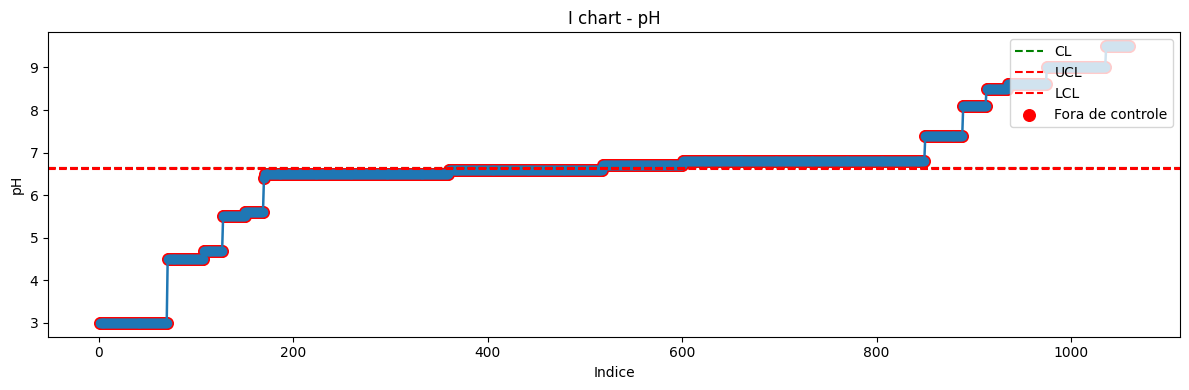

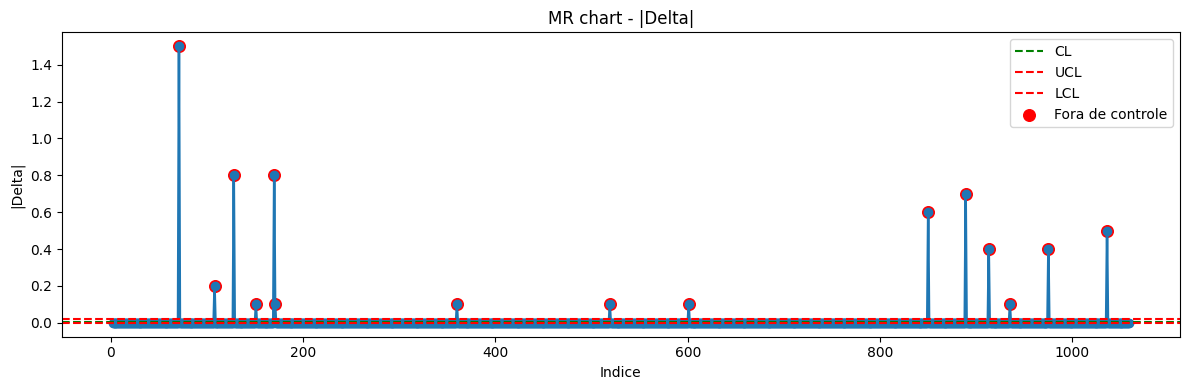


=== pH :: Xbar-R rolling (n=5, step=1) ===
A2=0.577, D3=0.0, D4=2.114
Xbarbar=6.7614, Rbar=0.4561
Xbar: LCL=6.4982, CL=6.7614, UCL=7.0246
R   : LCL=0.0000, CL=0.4561, UCL=0.9643


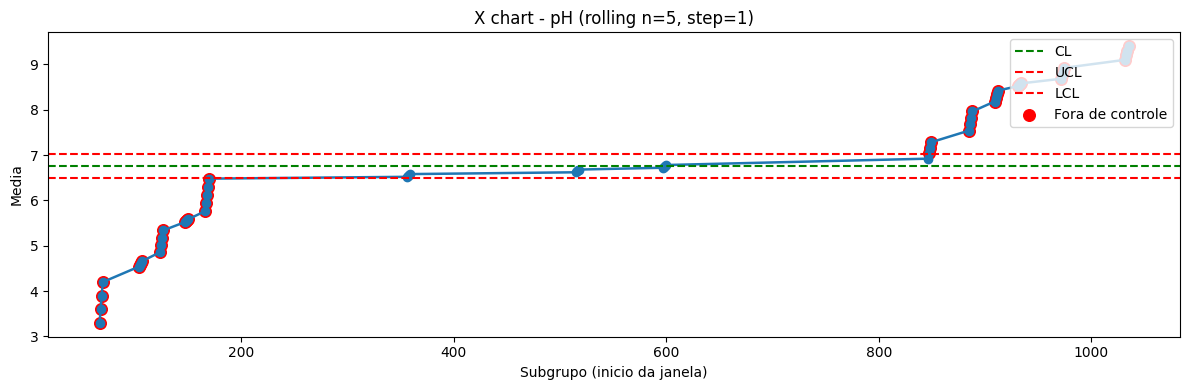

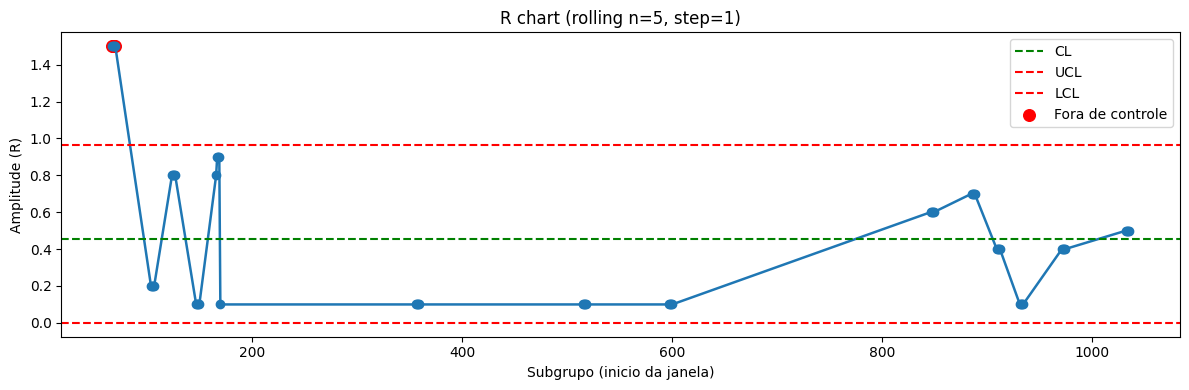


Variavel: Temperature
N observacoes: 1059


,Temperature
count,1059.000000
mean,44.226629
std,10.098364
min,34.000000
25%,38.000000
50%,41.000000
75%,45.000000
max,90.000000



=== Temperature :: I-MR ===
Xbar=44.2266 | MRbar=0.2741 | sigma~0.2430
I:  LCL=43.4976, CL=44.2266, UCL=44.9556
MR: LCL=0.0000, CL=0.2741, UCL=0.8955


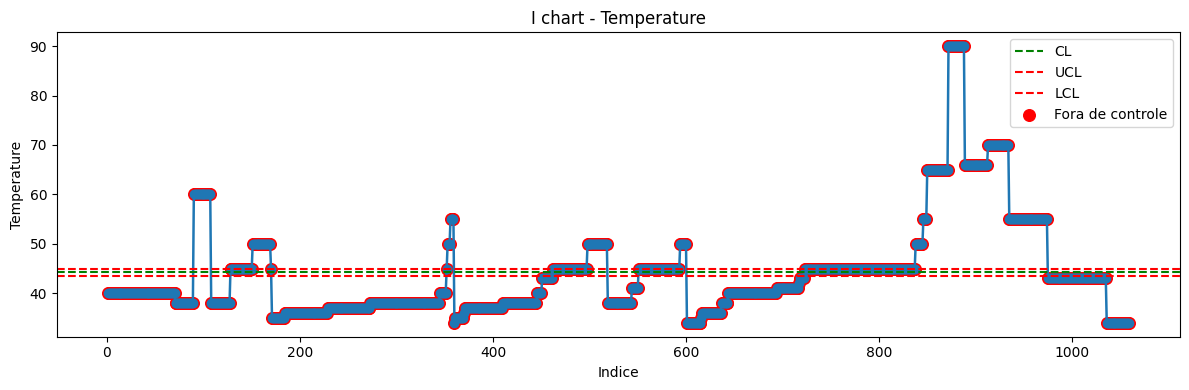

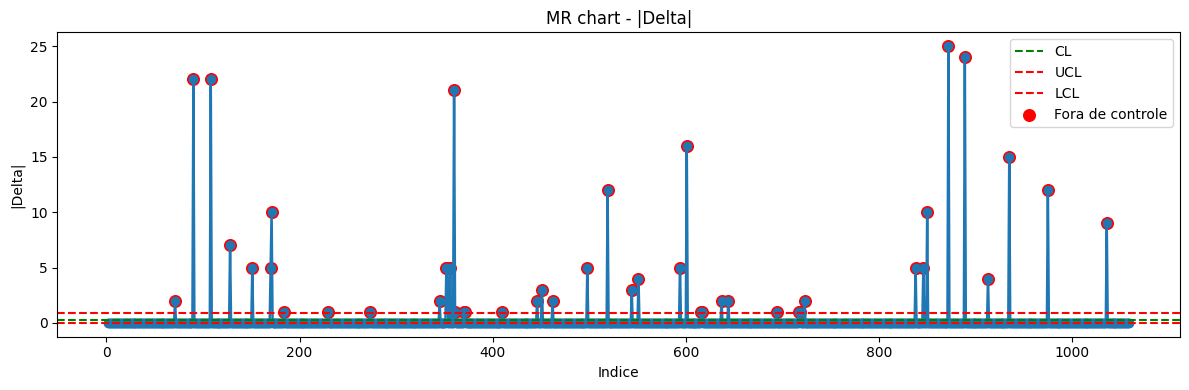


=== Temperature :: Xbar-R rolling (n=5, step=1) ===
A2=0.577, D3=0.0, D4=2.114
Xbarbar=45.6832, Rbar=7.1863
Xbar: LCL=41.5367, CL=45.6832, UCL=49.8297
R   : LCL=0.0000, CL=7.1863, UCL=15.1919


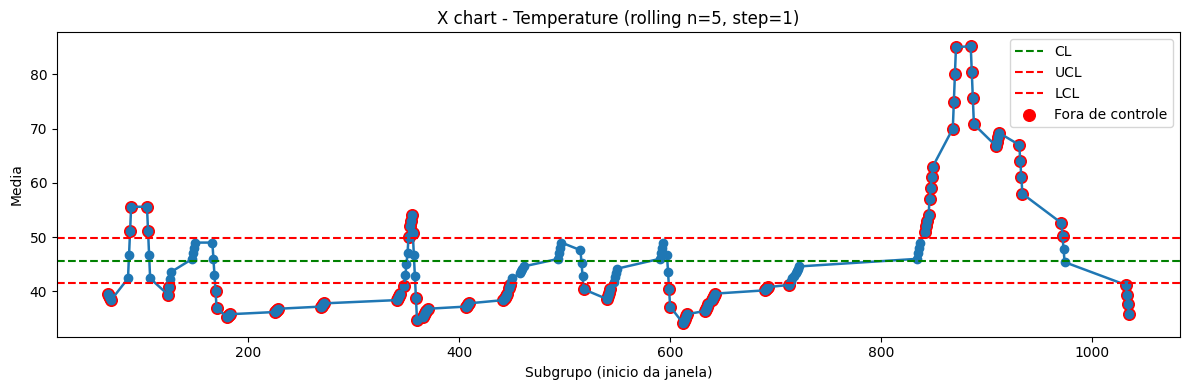

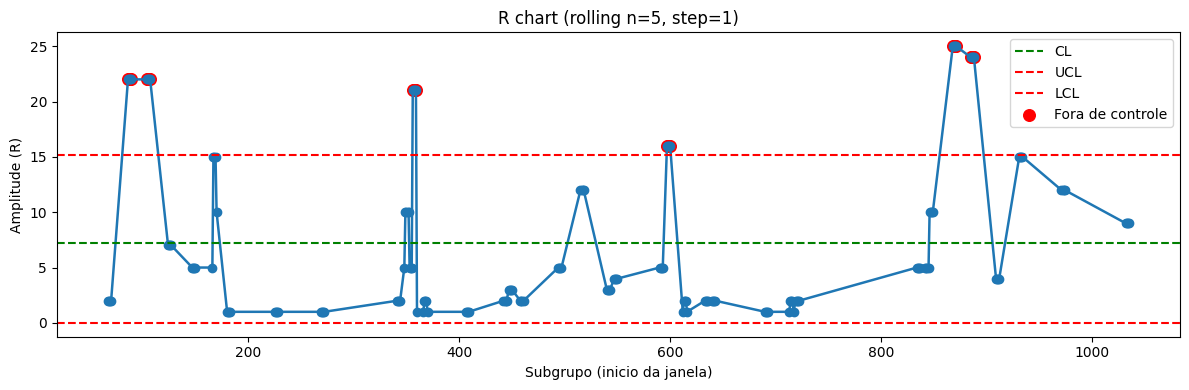

Pronto! Gerado I-MR (sempre) e Xbar-R rolling (se USE_ROLLING_XBARR=True).


In [7]:
variaveis = [c for c in ["pH", "Temperature"] if c in df.columns]
if not variaveis:
    raise ValueError("Planilha nao contem 'pH' nem 'Temperature'.")

for var in variaveis:
    print("\n" + "="*70)
    print(f"Variavel: {var}")
    y = pd.to_numeric(df[var], errors="coerce").dropna().astype(float).reset_index(drop=True)
    print("N observacoes:", len(y))
    display(y.describe())

    imr(y, var)

    if USE_ROLLING_XBARR:
        xbar_r_rolling_pipeline(y, var, n=ROLL_N, step=ROLL_STEP, min_r=ROLL_MIN_R)

print("Pronto! Gerado I-MR (sempre) e Xbar-R rolling (se USE_ROLLING_XBARR=True).")


## Passo 8 — Interpretacao e proximos passos
Use os graficos para monitorar estabilidade. Pontos fora de UCL/LCL sugerem causas especiais. MR alto indica mudancas bruscas; R alto indica variabilidade interna de subgrupo. Muitos R~0 sugerem subgrupos nao racionais — prefira I-MR. Extensoes: Regras Western Electric, capabilidade (Cp/Cpk) e exportacao de figuras.